# Education Project: Predicting ACT Scores based on Socio-Economic Factors
### Brisa Halviatti for Data 5100 Assignment 2


Project Overview
* Objective: The goal of this project is to predict ACT scores of students using socioeconomic data about the school, location, and enviornment
* Domain: Education
* Key Techniques: Regression Analysis (in []notebook)

## Load and Preview Datasources

In [1]:
# Import pandas, numpy, and matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# data visualization
import seaborn as sns
# set the plotting style
sns.set_style("whitegrid")
import plotly.offline as po
import plotly.graph_objs as pg
po.init_notebook_mode(connected=True)

# Model preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Modeling
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Model metrics and analysis
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.anova import anova_lm
from patsy import dmatrices

EdGap Data

In [2]:
edgap = pd.read_excel(
    'https://raw.githubusercontent.com/brian-fischer/DATA-5100/main/EdGap_data.xlsx'
    ,dtype={'NCESSCH School ID': object})

C:\Users\brisa\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning:

Unknown extension is not supported and will be removed



In [3]:
edgap.head()

,NCESSCH School ID,CT Unemployment Rate,CT Pct Adults with College Degree,CT Pct Childre In Married Couple Family,CT Median Household Income,School ACT average (or equivalent if SAT score),School Pct Free and Reduced Lunch
0,100001600143,0.117962,0.445283,0.346495,42820.0,20.433455,0.066901
1,100008000024,0.063984,0.662765,0.767619,89320.0,19.498168,0.112412
2,100008000225,0.056460,0.701864,0.713090,84140.0,19.554335,0.096816
3,100017000029,0.044739,0.692062,0.641283,56500.0,17.737485,0.296960
4,100018000040,0.077014,0.640060,0.834402,54015.0,18.245421,0.262641


School Info Data

In [4]:
school_info = pd.read_csv(r'C:\Users\brisa\Documents\0 Seattle U\DATA 5100 Foundations\education\data\ccd_sch_029_1617_w_1a_11212017.csv'
                         ,encoding='unicode_escape')

C:\Users\brisa\AppData\Local\Temp\ipykernel_26800\1003416712.py:1: DtypeWarning:

Columns (6,9,14,15,18,19,21,22,25,26,29,31,35,39,41,42) have mixed types. Specify dtype option on import or set low_memory=False.



In [5]:
pd.set_option('display.max_columns', None)
school_info.head()

,SCHOOL_YEAR,FIPST,STATENAME,ST,SCH_NAME,LEA_NAME,STATE_AGENCY_NO,UNION,ST_LEAID,LEAID,ST_SCHID,NCESSCH,SCHID,MSTREET1,MSTREET2,MSTREET3,MCITY,MSTATE,MZIP,MZIP4,LSTREET1,LSTREET2,LSTREET3,LCITY,LSTATE,LZIP,LZIP4,PHONE,WEBSITE,SY_STATUS,SY_STATUS_TEXT,UPDATED_STATUS,UPDATED_STATUS_TEXT,EFFECTIVE_DATE,SCH_TYPE_TEXT,SCH_TYPE,RECON_STATUS,OUT_OF_STATE_FLAG,CHARTER_TEXT,CHARTAUTH1,CHARTAUTHN1,CHARTAUTH2,CHARTAUTHN2,NOGRADES,G_PK_OFFERED,G_KG_OFFERED,G_1_OFFERED,G_2_OFFERED,G_3_OFFERED,G_4_OFFERED,G_5_OFFERED,G_6_OFFERED,G_7_OFFERED,G_8_OFFERED,G_9_OFFERED,G_10_OFFERED,G_11_OFFERED,G_12_OFFERED,G_13_OFFERED,G_UG_OFFERED,G_AE_OFFERED,GSLO,GSHI,LEVEL,IGOFFERED
0,2016-2017,1,ALABAMA,AL,Sequoyah Sch - Chalkville Campus,Alabama Youth Services,1,NaN,AL-210,100002,AL-210-0020,1.000020e+10,100277.0,P O Box 9486,NaN,NaN,Birmingham,AL,35220,NaN,1000 Industrial School Road,NaN,NaN,Birmingham,AL,35220,NaN,(205)680-8574,http://www.dys.alabama.gov,1,Open,1,Open,03/03/2010,Alternative School,4,No,No,No,NaN,NaN,NaN,NaN,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No,07,12,High,As reported
1,2016-2017,1,ALABAMA,AL,Camps,Alabama Youth Services,1,NaN,AL-210,100002,AL-210-0050,1.000020e+10,101667.0,P O Box 66,NaN,NaN,Mt Meigs,AL,36057,NaN,1601 County Rd. 57,NaN,NaN,Prattville,AL,36067,NaN,(334)215-3850,http://www.dys.alabama.gov,1,Open,1,Open,03/03/2010,Alternative School,4,No,No,No,NaN,NaN,NaN,NaN,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No,07,12,High,As reported
2,2016-2017,1,ALABAMA,AL,Det Ctr,Alabama Youth Services,1,NaN,AL-210,100002,AL-210-0060,1.000020e+10,101670.0,P O Box 66,NaN,NaN,Mt Meigs,AL,36057,NaN,2109 Bashi Rd Bldg 509,NaN,NaN,Thomasville,AL,36784,NaN,(334)215-3850,http://www.dys.alabama.gov,1,Open,1,Open,03/03/2010,Alternative School,4,No,No,No,NaN,NaN,NaN,NaN,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No,07,12,High,As reported
3,2016-2017,1,ALABAMA,AL,Wallace Sch - Mt Meigs Campus,Alabama Youth Services,1,NaN,AL-210,100002,AL-210-0030,1.000020e+10,101705.0,P O Box 66,NaN,NaN,Mount Meigs,AL,36057,NaN,1000 Industrial School Road,NaN,NaN,Mount Meigs,AL,36057,NaN,(334)215-6039,http://www.dys.alabama.gov,1,Open,1,Open,03/03/2010,Alternative School,4,No,No,No,NaN,NaN,NaN,NaN,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No,07,12,High,As reported
4,2016-2017,1,ALABAMA,AL,McNeel Sch - Vacca Campus,Alabama Youth Services,1,NaN,AL-210,100002,AL-210-0040,1.000020e+10,101706.0,8950 Roebuck Blvd,NaN,NaN,Birmingham,AL,35206,NaN,8950 Roebuck Blvd,NaN,NaN,Birmingham,AL,35206,NaN,(205)838-4981,http://www.dys.alabama.gov,1,Open,1,Open,03/03/2010,Alternative School,4,No,No,No,NaN,NaN,NaN,NaN,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No,07,12,High,As reported


Higher Education Locations, by Zip Code

In [6]:
higher_ed_locations = pd.read_csv('https://github.com/brisamh/education/raw/refs/heads/main/data/hd2017.csv', encoding="unicode_escape")

In [7]:
higher_ed_locations.head()

,UNITID,INSTNM,IALIAS,ADDR,CITY,STABBR,ZIP,FIPS,OBEREG,CHFNM,CHFTITLE,GENTELE,EIN,DUNS,OPEID,OPEFLAG,WEBADDR,ADMINURL,FAIDURL,APPLURL,NPRICURL,VETURL,ATHURL,DISAURL,SECTOR,ICLEVEL,CONTROL,HLOFFER,UGOFFER,GROFFER,HDEGOFR1,DEGGRANT,HBCU,HOSPITAL,MEDICAL,TRIBAL,LOCALE,OPENPUBL,ACT,NEWID,DEATHYR,CLOSEDAT,CYACTIVE,POSTSEC,PSEFLAG,PSET4FLG,RPTMTH,INSTCAT,C15BASIC,C15IPUG,C15IPGRD,C15UGPRF,C15ENPRF,C15SZSET,CCBASIC,CARNEGIE,LANDGRNT,INSTSIZE,F1SYSTYP,F1SYSNAM,F1SYSCOD,CBSA,CBSATYPE,CSA,NECTA,COUNTYCD,COUNTYNM,CNGDSTCD,LONGITUD,LATITUDE,DFRCGID,DFRCUSCG
0,100654,Alabama A & M University,AAMU,4900 Meridian Street,Normal,AL,35762,1,5,"Dr. Andrew Hugine, Jr.",President,2563725000,636001109,197216455,00100200,1,www.aamu.edu/,www.aamu.edu/Admissions/Pages/default.aspx,www.aamu.edu/Admissions/fincialaid/Pages/defau...,https://ssb.aamu.edu/PROD/bwskalog.P_DispLoginNon,www2.aamu.edu/scripts/netpricecalc/npcalc.htm,,www.aamu.edu/administrativeoffices/irpsp/insti...,www.aamu.edu/administrativeoffices/VADS/Pages/...,1,1,1,9,1,1,12,1,1,2,2,2,12,1,A,-2,-2,-2,1,1,1,1,1,2,18,16,18,10,4,13,18,16,1,3,2,-2,-2,26620,1,290,-2,1089,Madison County,105,-86.568502,34.783368,122,1
1,100663,University of Alabama at Birmingham,,Administration Bldg Suite 1070,Birmingham,AL,35294-0110,1,5,Ray L. Watts,President,2059344011,636005396,063690705,00105200,1,www.uab.edu,www.uab.edu/students/undergraduate-admissions,www.uab.edu/students/paying-for-college,https://idm.uab.edu/myuab/login?from=ugadmapp,uab.studentaidcalculator.com/survey.aspx,www.uab.edu/students/veterans,www.uab.edu/registrar/students,www.uab.edu/students/disability/,1,1,1,9,1,1,11,1,2,1,1,2,12,1,A,-2,-2,-2,1,1,1,1,1,2,15,14,17,9,5,15,15,15,2,5,1,The University of Alabama System,101050,13820,1,142,-2,1073,Jefferson County,107,-86.799345,33.505697,109,1
2,100690,Amridge University,Southern Christian University |Regions University,1200 Taylor Rd,Montgomery,AL,36117-3553,1,5,Michael C.Turner,President,33438738777528,237034324,126307792,02503400,1,www.amridgeuniversity.edu,www.amridgeuniversity.edu/admissions/,www.amridgeuniversity.edu/financialaid/,https://www2.amridgeuniversity.edu/Amridge/Log...,www2.amridgeuniversity.edu:9091/,www.amridgeuniversity.edu/admissions/military/,,www.amridgeuniversity.edu/pdf/Amridge%20Univer...,2,1,2,9,1,1,12,1,2,2,2,2,12,1,A,-2,-2,-2,1,1,1,1,1,2,20,19,13,5,5,6,21,51,2,1,2,-2,-2,33860,1,-2,-2,1101,Montgomery County,102,-86.174010,32.362609,141,2
3,100706,University of Alabama in Huntsville,UAH |University of Alabama Huntsville,301 Sparkman Dr,Huntsville,AL,35899,1,5,Robert A. Altenkirch,President,2568246120,630520830,949687123,00105500,1,www.uah.edu,https://www.uah.edu/admissions,finaid.uah.edu/,register.uah.edu,finaid.uah.edu/,www.uah.edu/admissions/graduate/financial-aid/...,www.uah.edu/heoa,www.uah.edu/health-and-wellness/disability-sup...,1,1,1,9,1,1,11,1,2,2,2,2,12,1,A,-2,-2,-2,1,1,1,1,1,2,16,17,17,9,4,12,15,16,2,3,1,The University of Alabama System,101050,26620,1,290,-2,1089,Madison County,105,-86.640449,34.724557,112,2
4,100724,Alabama State University,,915 S Jackson Street,Montgomery,AL,36104-0271,1,5,Quinton T. Ross,President,3342294100,636001101,040672685,00100500,1,www.alasu.edu,www.alasu.edu/admissions/index.aspx,www.alasu.edu/cost-aid/index.aspx,www.alasu.edu/admissions/undergrad-admissions/...,www.alasu.edu/cost-aid/forms/calculator/index....,,www.alasu.edu/search-results/index.aspx,www.alasu.edu/about-asu/the-campus/disability-...,1,1,1,9,1,1,11,1,1,2,2,2,12,1,A,-2,-2,-2,1,1,1,1,1,2,19,13,13,10,3,13,18,21,2,2,2,-2,-2,33860,1,-2,-2,1101,Montgomery County,107,-86.295677,32.364317,131,1


CRDC Referrals to Law Enforcement and Arrest Data, by School

In [8]:
referrals_arrest = pd.read_csv('https://raw.githubusercontent.com/brisamh/education/refs/heads/main/data/Referrals%20and%20Arrests.csv', encoding="unicode_escape")

C:\Users\brisa\AppData\Local\Temp\ipykernel_26800\495936919.py:1: DtypeWarning:

Columns (2,6) have mixed types. Specify dtype option on import or set low_memory=False.



In [9]:
referrals_arrest.head()

,LEA_STATE,LEA_STATE_NAME,LEAID,LEA_NAME,SCHID,SCH_NAME,COMBOKEY,JJ,SCH_DISCWODIS_REF_HI_M,SCH_DISCWODIS_REF_HI_F,SCH_DISCWODIS_REF_AM_M,SCH_DISCWODIS_REF_AM_F,SCH_DISCWODIS_REF_AS_M,SCH_DISCWODIS_REF_AS_F,SCH_DISCWODIS_REF_HP_M,SCH_DISCWODIS_REF_HP_F,SCH_DISCWODIS_REF_BL_M,SCH_DISCWODIS_REF_BL_F,SCH_DISCWODIS_REF_WH_M,SCH_DISCWODIS_REF_WH_F,SCH_DISCWODIS_REF_TR_M,SCH_DISCWODIS_REF_TR_F,TOT_DISCWODIS_REF_M,TOT_DISCWODIS_REF_F,SCH_DISCWODIS_REF_LEP_M,SCH_DISCWODIS_REF_LEP_F,SCH_DISCWDIS_REF_IDEA_HI_M,SCH_DISCWDIS_REF_IDEA_HI_F,SCH_DISCWDIS_REF_IDEA_AM_M,SCH_DISCWDIS_REF_IDEA_AM_F,SCH_DISCWDIS_REF_IDEA_AS_M,SCH_DISCWDIS_REF_IDEA_AS_F,SCH_DISCWDIS_REF_IDEA_HP_M,SCH_DISCWDIS_REF_IDEA_HP_F,SCH_DISCWDIS_REF_IDEA_BL_M,SCH_DISCWDIS_REF_IDEA_BL_F,SCH_DISCWDIS_REF_IDEA_WH_M,SCH_DISCWDIS_REF_IDEA_WH_F,SCH_DISCWDIS_REF_IDEA_TR_M,SCH_DISCWDIS_REF_IDEA_TR_F,TOT_DISCWDIS_REF_IDEA_M,TOT_DISCWDIS_REF_IDEA_F,SCH_DISCWDIS_REF_LEP_M,SCH_DISCWDIS_REF_LEP_F,SCH_DISCWDIS_REF_504_M,SCH_DISCWDIS_REF_504_F,SCH_DISCWODIS_ARR_HI_M,SCH_DISCWODIS_ARR_HI_F,SCH_DISCWODIS_ARR_AM_M,SCH_DISCWODIS_ARR_AM_F,SCH_DISCWODIS_ARR_AS_M,SCH_DISCWODIS_ARR_AS_F,SCH_DISCWODIS_ARR_HP_M,SCH_DISCWODIS_ARR_HP_F,SCH_DISCWODIS_ARR_BL_M,SCH_DISCWODIS_ARR_BL_F,SCH_DISCWODIS_ARR_WH_M,SCH_DISCWODIS_ARR_WH_F,SCH_DISCWODIS_ARR_TR_M,SCH_DISCWODIS_ARR_TR_F,TOT_DISCWODIS_ARR_M,TOT_DISCWODIS_ARR_F,SCH_DISCWODIS_ARR_LEP_M,SCH_DISCWODIS_ARR_LEP_F,SCH_DISCWDIS_ARR_IDEA_HI_M,SCH_DISCWDIS_ARR_IDEA_HI_F,SCH_DISCWDIS_ARR_IDEA_AM_M,SCH_DISCWDIS_ARR_IDEA_AM_F,SCH_DISCWDIS_ARR_IDEA_AS_M,SCH_DISCWDIS_ARR_IDEA_AS_F,SCH_DISCWDIS_ARR_IDEA_HP_M,SCH_DISCWDIS_ARR_IDEA_HP_F,SCH_DISCWDIS_ARR_IDEA_BL_M,SCH_DISCWDIS_ARR_IDEA_BL_F,SCH_DISCWDIS_ARR_IDEA_WH_M,SCH_DISCWDIS_ARR_IDEA_WH_F,SCH_DISCWDIS_ARR_IDEA_TR_M,SCH_DISCWDIS_ARR_IDEA_TR_F,TOT_DISCWDIS_ARR_IDEA_M,TOT_DISCWDIS_ARR_IDEA_F,SCH_DISCWDIS_ARR_LEP_M,SCH_DISCWDIS_ARR_LEP_F,SCH_DISCWDIS_ARR_504_M,SCH_DISCWDIS_ARR_504_F
0,AL,ALABAMA,100002,Alabama Youth Services,1017,Wallace Sch - Mt Meigs Campus,10000201705,Yes,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9
1,AL,ALABAMA,100002,Alabama Youth Services,1017,McNeel Sch - Vacca Campus,10000201706,Yes,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9
2,AL,ALABAMA,100002,Alabama Youth Services,1018,Alabama Youth Services,10000201876,No,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,AL,ALABAMA,100002,Alabama Youth Services,1999,AUTAUGA CAMPUS,10000299995,Yes,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9
4,AL,ALABAMA,100005,Albertville City,1008,Albertville Middle School,10000500870,No,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Generated table from CCD ELSI Table Generator https://nces.ed.gov/ccd/elsi/tableGenerator.aspx

In [10]:
ccd_data = pd.read_excel(
    'https://raw.githubusercontent.com/brisamh/education/main/data/CCD_elsi_table_generator_data.xlsx'
    ,dtype={'School ID (12-digit) - NCES Assigned [Public School] Latest available year': object
           ,'Agency ID - NCES Assigned [Public School] Latest available year': object}
)

create a dataframe for states that require the ACT or not based on data found online. Some states the SAT/ACT are Mandatory, others the test is Provided for free but is not mandated. If the state is not in this list, it is optional
https://www.piqosity.com/act-sat-graduation-requirements-by-state/

In [11]:
## Had ChatGPT help me turn the list from article into a dataframe to save me a bunch of manual work

# Lists of states by testing type
provided_states = ["AK", "AR", "AZ", "FL", "GA", "MD", "MN", "MS", "NY", "OR", "PA", "VA", "SC", "TX", "WA"]
mandatory_states = ["CO", "CT", "DE", "DC", "ID", "IN", "KY", "MI", "NH", "NM", "RI", "WV"]

# List of all US state codes
all_states = [
    "AL","AK","AZ","AR","CA","CO","CT","DE","FL","GA","HI","ID","IL","IN","IA","KS","KY","LA","ME","MD",
    "MA","MI","MN","MS","MO","MT","NE","NV","NH","NJ","NM","NY","NC","ND","OH","OK","OR","PA","RI","SC",
    "SD","TN","TX","UT","VT","VA","WA","WV","WI","WY","DC"
]

# Assign testing status
state_testing_data = {
    "state": all_states,
    "testing": [
        "Provided" if state in provided_states else
        "Mandatory" if state in mandatory_states else
        "Optional"
        for state in all_states
    ]
}

# Create DataFrame
state_testing = pd.DataFrame(state_testing_data)

state_testing.head()


,state,testing
0,AL,Optional
1,AK,Provided
2,AZ,Provided
3,AR,Provided
4,CA,Optional


## Data Cleaning, Preprocessing, and EDA

We will focus on the relationships between EdGap data and School Info, examine the data quality, perform any neccessary transformations, then join the data. Once we have a single data frame representing the combined data, we will continue with the remaining data sources one by one

In [12]:
edgap.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7986 entries, 0 to 7985
Data columns (total 7 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   NCESSCH School ID                                7986 non-null   object 
 1   CT Unemployment Rate                             7972 non-null   float64
 2   CT Pct Adults with College Degree                7973 non-null   float64
 3   CT Pct Childre In Married Couple Family          7961 non-null   float64
 4   CT Median Household Income                       7966 non-null   float64
 5   School ACT average (or equivalent if SAT score)  7986 non-null   float64
 6   School Pct Free and Reduced Lunch                7986 non-null   float64
dtypes: float64(6), object(1)
memory usage: 436.9+ KB


EdGap data has some null values, data types look mostly correct, but we have data for fewer than 8k schools

In [13]:
school_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102183 entries, 0 to 102182
Data columns (total 65 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   SCHOOL_YEAR          102183 non-null  object 
 1   FIPST                102183 non-null  int64  
 2   STATENAME            102183 non-null  object 
 3   ST                   102183 non-null  object 
 4   SCH_NAME             102183 non-null  object 
 5   LEA_NAME             102183 non-null  object 
 6   STATE_AGENCY_NO      102183 non-null  object 
 7   UNION                2533 non-null    float64
 8   ST_LEAID             102183 non-null  object 
 9   LEAID                102183 non-null  object 
 10  ST_SCHID             102183 non-null  object 
 11  NCESSCH              102181 non-null  float64
 12  SCHID                102181 non-null  float64
 13  MSTREET1             102181 non-null  object 
 14  MSTREET2             1825 non-null    object 
 15  MSTREET3         

School Info has more than 100k rows, location/identifying info is mostly non-null

School ID (NCESSCH) is a float here, but an object in the other dataset
* EdGap dataset does not contain all the schools 
* There are missing values in each
* each dataset is in a tidy/long format
* data types for the variables of interest look correct but mismatch types for the keys

### Begin EDA to visualize data before diving into pre-processing
The goal of this analysis is to run a regression analysis to determine the relationship between ACT scores and various predictors of socio-economic factors. We want to check those relationships before we spend too much time or energy on data that won't help our goal

We will use a pairplot to visualize all the relationships in the EdGap data, dropping School ID since it is not real data

<function matplotlib.pyplot.show(close=None, block=None)>

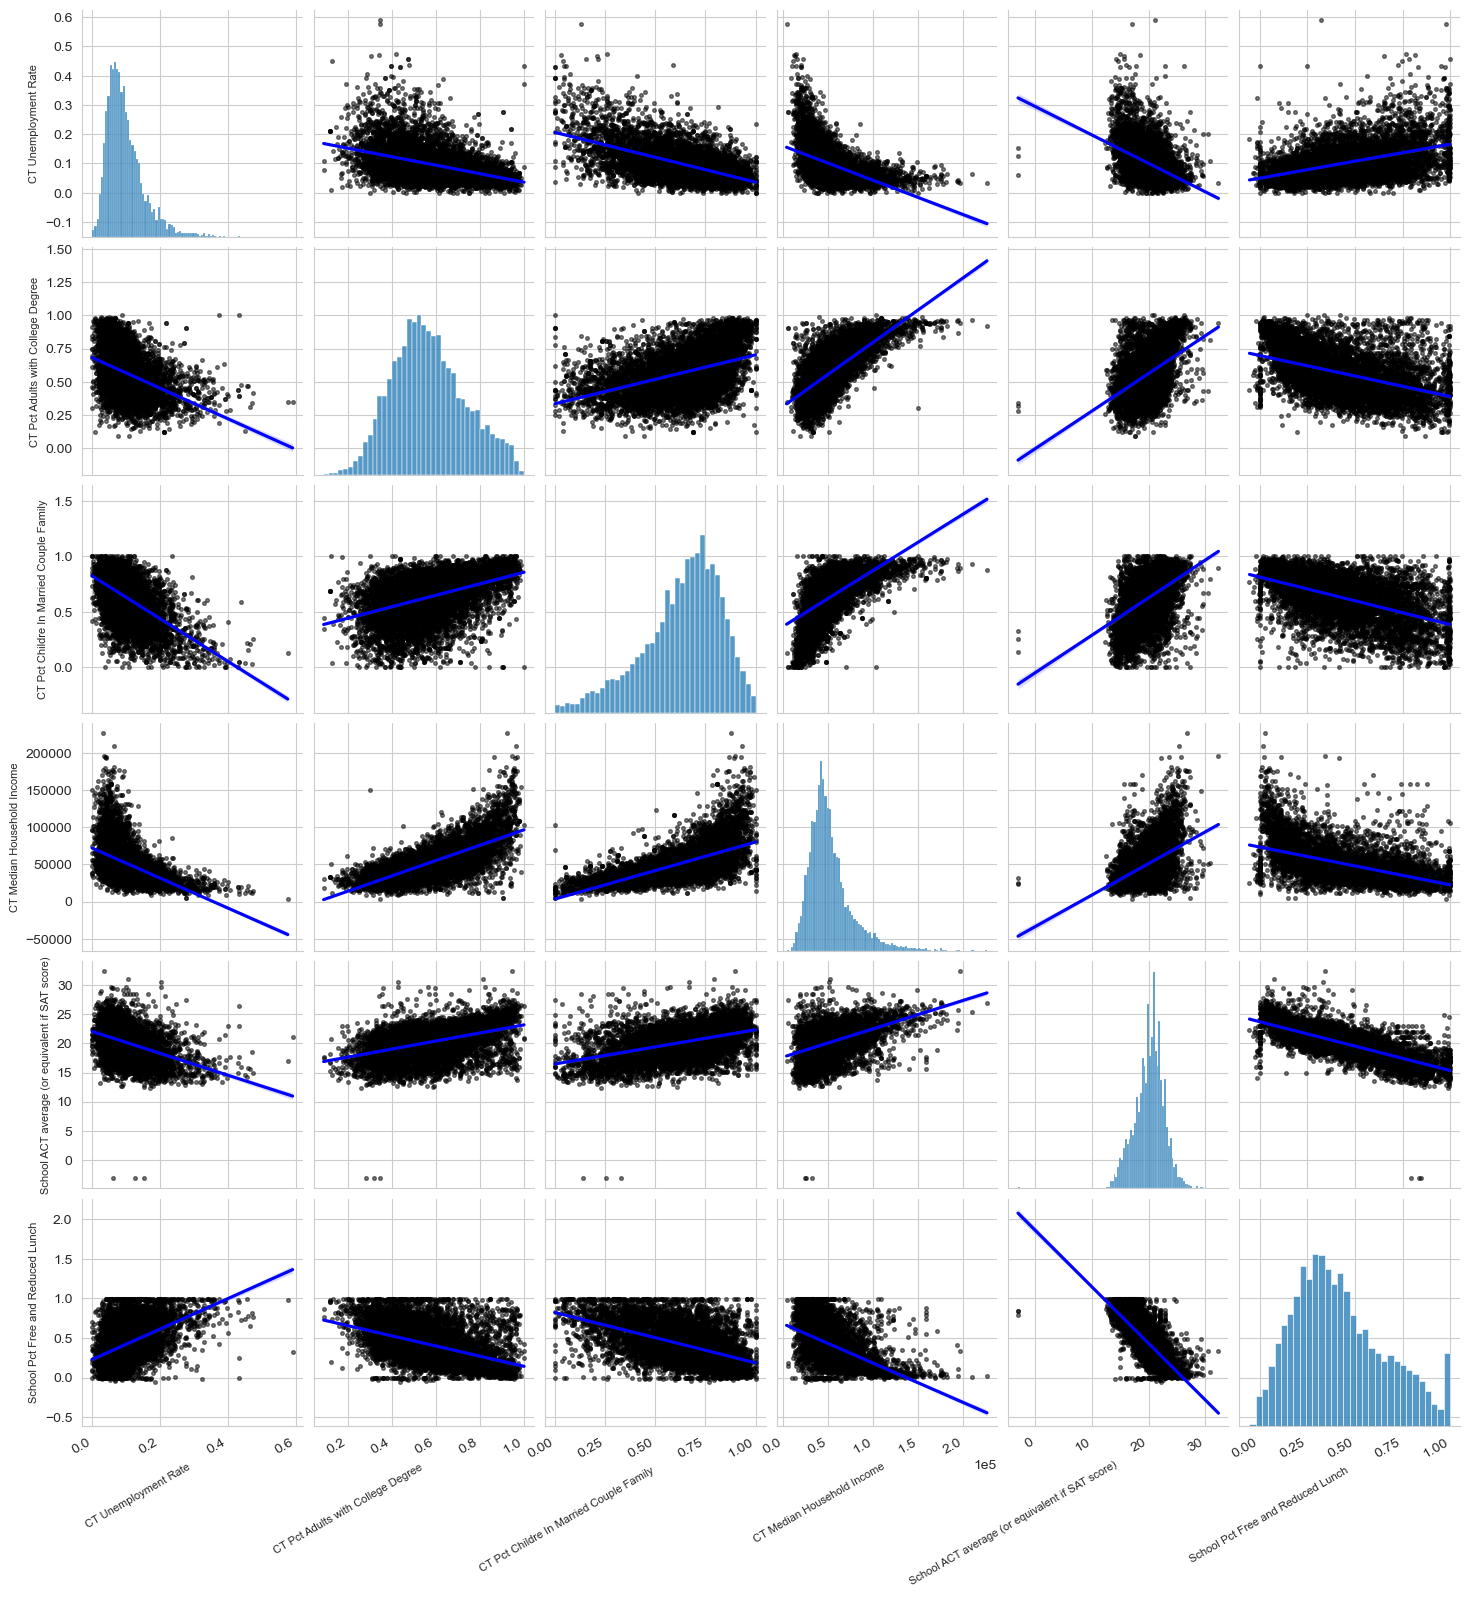

In [14]:
fig = sns.pairplot(
    edgap.drop(columns='NCESSCH School ID')
    ,kind='reg' ## regression 
    ,plot_kws={
        "line_kws":{'color':'blue'},
        "scatter_kws":{"alpha":0.5,"color":"k","s":7},
        },
)

for ax in fig.axes.flat:
    if ax.get_xlabel()=='CT Median Household Income':
        ax.ticklabel_format(style='sci',axis='x',scilimits=(0,0)) ## apply sci notation
    ax.set_xlabel(ax.get_xlabel(),fontsize=8, rotation=30, ha='right') ## x axis label size and rotation
    ax.set_ylabel(ax.get_ylabel(),fontsize=8) ## y axis label size
    
    ## rotate x axis tick labels
    plt.setp(ax.get_xticklabels(),rotation=30,ha='right')
plt.show
    
    

This is also a good opportunity for quality control: note that there are negative values in the ACT scores (does not pass sanity check). We have added regression lines by adding in kind='reg' 

Some preliminary indication of relationships between variables and ACT Scores, we can visualize more directly:

<function matplotlib.pyplot.show(close=None, block=None)>

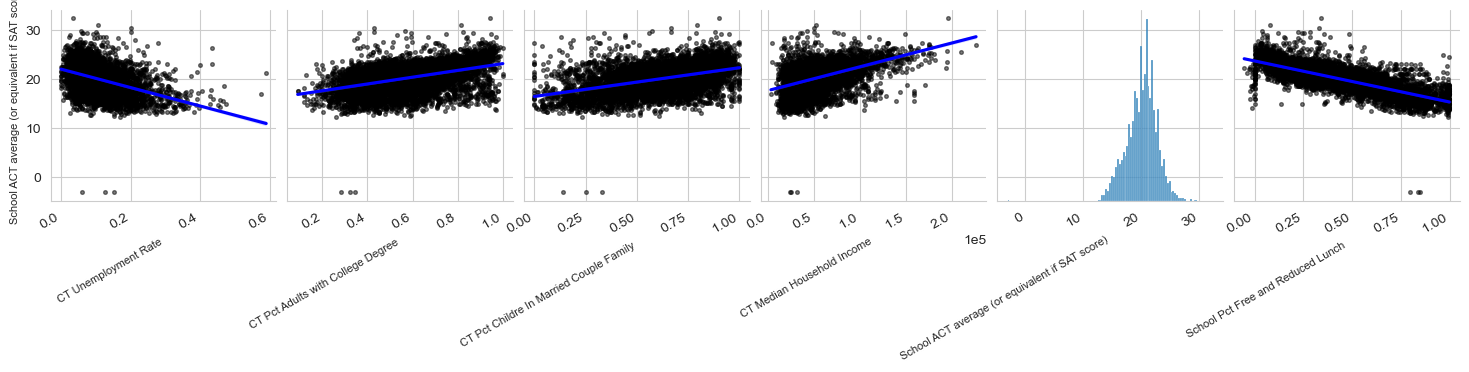

In [15]:
fig = sns.pairplot(
    edgap.drop(columns='NCESSCH School ID')
    ## now we'll see a single row
    ,y_vars=['School ACT average (or equivalent if SAT score)']
    ,kind='reg' ## regression 
    ,plot_kws={
        "line_kws":{'color':'blue'},
        "scatter_kws":{"alpha":0.5,"color":"k","s":7},
        },
)

for ax in fig.axes.flat:
    if ax.get_xlabel()=='CT Median Household Income':
        ax.ticklabel_format(style='sci',axis='x',scilimits=(0,0)) ## apply sci notation
    ax.set_xlabel(ax.get_xlabel(),fontsize=8, rotation=30, ha='right') ## x axis label size and rotation
    ax.set_ylabel(ax.get_ylabel(),fontsize=8) ## y axis label size
    
    ## rotate x axis tick labels
    plt.setp(ax.get_xticklabels(),rotation=30,ha='right')
plt.show
    
    

* there does appear to be a relationship between the socioeconomic variables and act scores
* there are some out of range ACT scores and percent lunch values that we need to address
* we shoul dhave confidence that it is worthwhile to spend time prepping this data

### Resume Data Pre-Processing for EdGap and School Info
We will begin by selecting the relevant subsets of the data. School Info has many columns but we do not need them all

In [16]:
school_info = school_info[['SCHOOL_YEAR', 'NCESSCH', 'LSTATE', 'LZIP', 'SCH_TYPE_TEXT', 'LEVEL', 'CHARTER_TEXT','SCH_NAME','LEAID','SCHID']
                         ]

school_info.head()

,SCHOOL_YEAR,NCESSCH,LSTATE,LZIP,SCH_TYPE_TEXT,LEVEL,CHARTER_TEXT,SCH_NAME,LEAID,SCHID
0,2016-2017,1.000020e+10,AL,35220,Alternative School,High,No,Sequoyah Sch - Chalkville Campus,100002,100277.0
1,2016-2017,1.000020e+10,AL,36067,Alternative School,High,No,Camps,100002,101667.0
2,2016-2017,1.000020e+10,AL,36784,Alternative School,High,No,Det Ctr,100002,101670.0
3,2016-2017,1.000020e+10,AL,36057,Alternative School,High,No,Wallace Sch - Mt Meigs Campus,100002,101705.0
4,2016-2017,1.000020e+10,AL,35206,Alternative School,High,No,McNeel Sch - Vacca Campus,100002,101706.0


We will also rename columns in both datasets so they align better and can be joined easier

In [17]:
edgap = edgap.rename(
    columns={
        "NCESSCH School ID":'id'
        ,"CT Pct Adults with College Degree" : "percent_college"
        ,"CT Unemployment Rate" : 'rate_unemployment'
        ,"CT Pct Childre In Married Couple Family" : 'percent_married'
        ,"CT Median Household Income" : "median_income"
        ,"School ACT average (or equivalent if SAT score)" : "average_act"
        ,"School Pct Free and Reduced Lunch" : "percent_lunch"
    })


In [18]:
edgap.head()

,id,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch
0,100001600143,0.117962,0.445283,0.346495,42820.0,20.433455,0.066901
1,100008000024,0.063984,0.662765,0.767619,89320.0,19.498168,0.112412
2,100008000225,0.056460,0.701864,0.713090,84140.0,19.554335,0.096816
3,100017000029,0.044739,0.692062,0.641283,56500.0,17.737485,0.296960
4,100018000040,0.077014,0.640060,0.834402,54015.0,18.245421,0.262641


In [19]:
school_info = school_info.rename(
    columns={
        "SCHOOL_YEAR" : 'year'
        ,"NCESSCH" : 'id'
        ,"LSTATE" : 'state'
        ,"LZIP" : 'zipcode'
        ,"SCH_TYPE_TEXT" : 'school_type'
        ,"LEVEL" : 'school_level'
        ,"CHARTER_TEXT" : "charter"
        ,'SCH_NAME':'sch_name'
        ,'LEAID':'leaid'
        ,'SCHID':'schid'
    })

In [20]:
school_info.head()

,year,id,state,zipcode,school_type,school_level,charter,sch_name,leaid,schid
0,2016-2017,1.000020e+10,AL,35220,Alternative School,High,No,Sequoyah Sch - Chalkville Campus,100002,100277.0
1,2016-2017,1.000020e+10,AL,36067,Alternative School,High,No,Camps,100002,101667.0
2,2016-2017,1.000020e+10,AL,36784,Alternative School,High,No,Det Ctr,100002,101670.0
3,2016-2017,1.000020e+10,AL,36057,Alternative School,High,No,Wallace Sch - Mt Meigs Campus,100002,101705.0
4,2016-2017,1.000020e+10,AL,35206,Alternative School,High,No,McNeel Sch - Vacca Campus,100002,101706.0


### Join EdGap Data to School Info Data Into Key Dataframe
Our first step is to ensure our keys match

In [21]:
school_info['id'] = school_info['id'].astype('object')
school_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102183 entries, 0 to 102182
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          102183 non-null  object 
 1   id            102181 non-null  object 
 2   state         102183 non-null  object 
 3   zipcode       102183 non-null  object 
 4   school_type   102181 non-null  object 
 5   school_level  102179 non-null  object 
 6   charter       102179 non-null  object 
 7   sch_name      102183 non-null  object 
 8   leaid         102183 non-null  object 
 9   schid         102181 non-null  float64
dtypes: float64(1), object(9)
memory usage: 7.8+ MB


Now we want to keep all the EdGap data, and bring in the school data where we have the data we care about, this will be a left join on the EdGap dataset

In [22]:
df = edgap.merge(
    school_info
    ,how='left'
    ,on='id')
df.head()

,id,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch,year,state,zipcode,school_type,school_level,charter,sch_name,leaid,schid
0,100001600143,0.117962,0.445283,0.346495,42820.0,20.433455,0.066901,2016-2017,DE,19804,Regular School,High,Yes,Delaware Military Academy,1000016,1000143.0
1,100008000024,0.063984,0.662765,0.767619,89320.0,19.498168,0.112412,2016-2017,DE,19709,Regular School,High,No,Middletown High School,1000080,1000024.0
2,100008000225,0.056460,0.701864,0.713090,84140.0,19.554335,0.096816,2016-2017,DE,19709,Regular School,High,No,Appoquinimink High School,1000080,1000225.0
3,100017000029,0.044739,0.692062,0.641283,56500.0,17.737485,0.296960,2016-2017,DE,19958,Regular School,High,No,Cape Henlopen High School,1000170,1000029.0
4,100018000040,0.077014,0.640060,0.834402,54015.0,18.245421,0.262641,2016-2017,DE,19934,Regular School,High,No,Caesar Rodney High School,1000180,1000040.0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7986 entries, 0 to 7985
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 7986 non-null   object 
 1   rate_unemployment  7972 non-null   float64
 2   percent_college    7973 non-null   float64
 3   percent_married    7961 non-null   float64
 4   median_income      7966 non-null   float64
 5   average_act        7986 non-null   float64
 6   percent_lunch      7986 non-null   float64
 7   year               7898 non-null   object 
 8   state              7898 non-null   object 
 9   zipcode            7898 non-null   object 
 10  school_type        7898 non-null   object 
 11  school_level       7898 non-null   object 
 12  charter            7898 non-null   object 
 13  sch_name           7898 non-null   object 
 14  leaid              7898 non-null   object 
 15  schid              7898 non-null   float64
dtypes: float64(7), object(9)

#### Quality Control
Check the min and max values in each column, we know there are some natural bounds like percentages between 0-100 or ensuring only positive numbers exist 

In [24]:
df.describe()

,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch,schid
count,7972.000000,7973.000000,7961.000000,7966.000000,7986.000000,7986.000000,7.898000e+03
mean,0.098730,0.568930,0.633440,52026.905222,20.181532,0.420651,3.316423e+06
std,0.058959,0.165704,0.196764,24228.057079,2.595201,0.239754,1.323264e+06
min,0.000000,0.091493,0.000000,3589.000000,-3.070818,-0.054545,1.000024e+06
25%,0.058655,0.450828,0.523810,36597.250000,18.600000,0.238501,2.101487e+06
50%,0.085649,0.554979,0.667594,46833.500000,20.400000,0.381570,3.604479e+06
75%,0.123376,0.676571,0.777135,61369.250000,21.910867,0.575447,4.207507e+06
max,0.590278,1.000000,1.000000,226181.000000,32.362637,0.998729,5.600448e+06


In [25]:
df.select_dtypes(include=['number']).agg(['min','max']).round(2)

,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch,schid
min,0.00,0.09,0.0,3589.0,-3.07,-0.05,1000024.0
max,0.59,1.00,1.0,226181.0,32.36,1.00,5600448.0


There are some extreme values that are unlikely, and some that are impossible. The clearly incorrect values we'll set to NaN

In [26]:
df.loc[df['percent_lunch']<0,'percent_lunch']= np.nan
df.loc[df['average_act']<1,'average_act'] = np.nan

#### Checking Categorical Data
Start with missing values

In [27]:
df.isna().sum().to_frame(name='Number of Missing values')

,Number of Missing values
id,0
rate_unemployment,14
percent_college,13
percent_married,25
median_income,20
average_act,3
percent_lunch,20
year,88
state,88
zipcode,88


In [28]:
percent_missing = df.isna().mean().round(4) * 100
percent_missing.to_frame(name='Percent Missing Values')

,Percent Missing Values
id,0.00
rate_unemployment,0.18
percent_college,0.16
percent_married,0.31
median_income,0.25
average_act,0.04
percent_lunch,0.25
year,1.10
state,1.10
zipcode,1.10


In [29]:
df['state'].value_counts()

state
TX    966
OH    693
PA    601
IL    590
MI    587
FL    441
NC    416
WI    386
NY    385
GA    383
NJ    354
MO    350
IN    347
TN    309
MA    292
WA    273
LA    245
KY    216
WY     38
DE     26
Name: count, dtype: int64

In [30]:
df['state'].nunique()

20

We can use plotly to visualize on a map where we have values, and what they are:

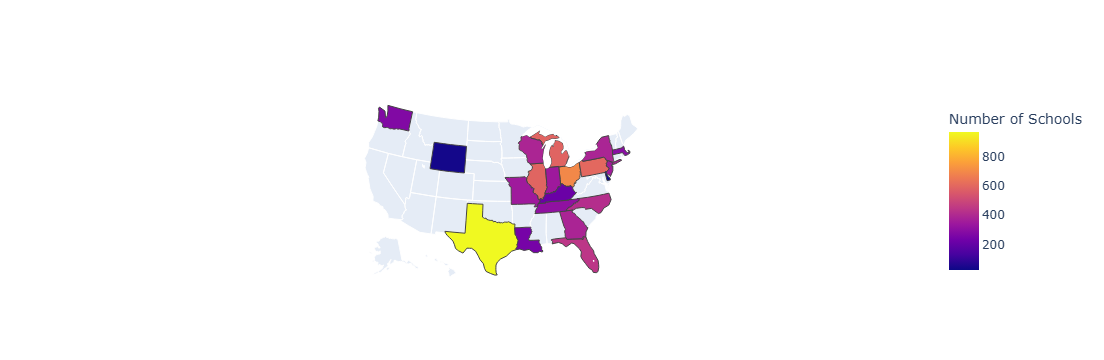

In [31]:
layout = dict(
    geo={"scope": "usa"},
    coloraxis_colorbar=dict(title="Number of Schools")
)

data = dict(
    type="choropleth",
    locations=df["state"].value_counts().index,
    locationmode="USA-states",
    z=df["state"].value_counts().values,
    coloraxis="coloraxis"
)

x = pg.Figure(data=[data], layout=layout)
po.iplot(x)

We are missing a lot of data simply from omission. We're going to drop the rows where the average ACT score is missing, since that is what we are interested in and we don't have many missing values

In [32]:
df=df.dropna(subset=['average_act'])

In [33]:
df.isna().sum().to_frame(name='Number of Missing Values')

,Number of Missing Values
id,0
rate_unemployment,14
percent_college,13
percent_married,25
median_income,20
average_act,0
percent_lunch,20
year,88
state,88
zipcode,88


If we were to drop rows that have NaNs for any socioeconomic variables, then we would negatively affect our analysis using the variables where the data was present. We will impute those rows based on relationships we see in the data

#### Data Imputation

In [34]:
predictor_variables = [
    'rate_unemployment'
    ,'percent_college'
    ,'percent_married'
    ,'median_income'
    ,'percent_lunch'
    ,'state'
    ,'charter'
]

We will use an interative imputer, what we're doing is using a type of regression analysis to look at relationships between predictors so if we're missing one i can use the best guess of it based on it's relationship to the other variables

In [35]:
imputer = IterativeImputer()

In [36]:
numerical_predictors = df[predictor_variables].select_dtypes(include='number').columns.to_list()

In [37]:
print(numerical_predictors)

['rate_unemployment', 'percent_college', 'percent_married', 'median_income', 'percent_lunch']


Fit the imputer with the data from those columns, here we are learning the relationships between thoes columns and then we can apply the transform method to actually replace the values

In [38]:
imputer.fit(df.loc[:, numerical_predictors])

IterativeImputer()

In [39]:
df.loc[:,numerical_predictors] = imputer.transform(df.loc[:,numerical_predictors])

In [40]:
df.isna().sum()

id                    0
rate_unemployment     0
percent_college       0
percent_married       0
median_income         0
average_act           0
percent_lunch         0
year                 88
state                88
zipcode              88
school_type          88
school_level         88
charter              88
sch_name             88
leaid                88
schid                88
dtype: int64

This concludes the pre-processing of our two key DataFrames, we will now move on to the remaining datasets

### Pre-Process Remaining Datasets

#### Prep and Clean Higher Education Institutions by Zip Code
We will begin with the Higher Ed data, using the addresses of all the registered Higher Education Institutions we will discern a Y/N flag for Zip Codes (or School Districts if needed) with at least one Higher Ed institution in the region (Zip Code)

In [41]:
higher_ed_locations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7153 entries, 0 to 7152
Data columns (total 72 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   UNITID    7153 non-null   int64  
 1   INSTNM    7153 non-null   object 
 2   IALIAS    7153 non-null   object 
 3   ADDR      7153 non-null   object 
 4   CITY      7153 non-null   object 
 5   STABBR    7153 non-null   object 
 6   ZIP       7153 non-null   object 
 7   FIPS      7153 non-null   int64  
 8   OBEREG    7153 non-null   int64  
 9   CHFNM     7153 non-null   object 
 10  CHFTITLE  7153 non-null   object 
 11  GENTELE   7153 non-null   object 
 12  EIN       7153 non-null   int64  
 13  DUNS      7153 non-null   object 
 14  OPEID     7153 non-null   object 
 15  OPEFLAG   7153 non-null   int64  
 16  WEBADDR   7153 non-null   object 
 17  ADMINURL  7153 non-null   object 
 18  FAIDURL   7153 non-null   object 
 19  APPLURL   7153 non-null   object 
 20  NPRICURL  7153 non-null   obje

We can remove the columns that are irrelevant to our analysis, then change the naming format of those that remain

In [42]:
higher_ed_locations = higher_ed_locations[['UNITID','INSTNM','ZIP','HLOFFER','INSTSIZE']]
higher_ed_locations.columns = ['institute_id','institute_name','zipcode','max_credential','size']

We will also convert all the numerical codes into categories, using the data documentation linked in the data folder

In [43]:
## convert numerical codes into categories
max_credential_map = {
    0: 'Other',
    1: 'Certificate <1 year',
    2: 'Certificate 1-2 years',
    3: 'Associate’s degree',
    4: 'Certificate 2-4 years',
    5: 'Bachelor’s degree',
    6: 'Postbaccalaureate certificate',
    7: 'Master’s degree',
    8: 'Post-master’s certificate',
    9: 'Doctor’s degree',
    'b': 'None / No answer',
    -2: 'Not applicable (first-professional only)',
    -3: 'Not available'
}

size_map = {
    1: 'Under 1,000',
    2: '1,000–4,999',
    3: '5,000–9,999',
    4: '10,000–19,999',
    5: '20,000+',
    -1: 'Not reported',
    -2: 'Not applicable',
    -3: 'Not available'
}

higher_ed_locations['size_cat'] = higher_ed_locations['size'].map(size_map)

## remap the columns 
higher_ed_locations['max_cred_cat'] = higher_ed_locations['max_credential'].map(max_credential_map)

higher_ed_locations.head()

,institute_id,institute_name,zipcode,max_credential,size,size_cat,max_cred_cat
0,100654,Alabama A & M University,35762,9,3,"5,000–9,999",Doctor’s degree
1,100663,University of Alabama at Birmingham,35294-0110,9,5,"20,000+",Doctor’s degree
2,100690,Amridge University,36117-3553,9,1,"Under 1,000",Doctor’s degree
3,100706,University of Alabama in Huntsville,35899,9,3,"5,000–9,999",Doctor’s degree
4,100724,Alabama State University,36104-0271,9,2,"1,000–4,999",Doctor’s degree


To be sure we have mapped everything correctly, check if there are any missing categories:

In [44]:
higher_ed_locations.loc[higher_ed_locations['size_cat'].isnull(), 'size'].unique()

array([], dtype=int64)

In [45]:
higher_ed_locations.loc[higher_ed_locations['max_cred_cat'].isnull(), 'max_credential'].unique()

array([], dtype=int64)

Start higher level, by just doing a count of institutiions regardless of size or credentials offered. If it proves relevant we can bring in the institution sizes or credentials offered 

In [46]:
higher_ed_zip = (higher_ed_locations.groupby(['zipcode'])['institute_id'].nunique()).reset_index()
higher_ed_zip.columns = ['zipcode','institution_count']
higher_ed_zip.head()

,zipcode,institution_count
0,00602,2
1,00602-0960,1
2,00603,4
3,00604-6150,1
4,00605,1


Some zip codes include hyper specific location data, we don't need this level of grainularity so we will use string functions to truncate the zip codes then re-aggregate

In [47]:
higher_ed_zip['zipcode'] = higher_ed_zip['zipcode'].str[:5]
higher_ed_zip.head()

,zipcode,institution_count
0,00602,2
1,00602,1
2,00603,4
3,00604,1
4,00605,1


In [48]:
higher_ed_zip = (higher_ed_zip.groupby(['zipcode'])['institution_count'].nunique()).reset_index()
higher_ed_zip.head()

,zipcode,institution_count
0,00602,2
1,00603,1
2,00604,1
3,00605,1
4,00612,1


#### Prep and Clean Referrals and Arrest Data
CRDC “Referrals and Arrests” tracks disciplinary actions involving law enforcement. The fields you listed correspond to counts of students referred to law enforcement or subjected to school-related arrests, disaggregated by disability status, race/ethnicity, gender, and program type

Data Dictionary for assistance:

* CH_	School-level count (as opposed to district-level).
* DISCWODIS	“Discipline Without Disabilities” — applies to students not served under IDEA (Individuals with Disabilities Education Act).
* DISCWDIS	“Discipline With Disabilities” — applies to students served under IDEA or Section 504.
* REF	Referred to law enforcement (but not necessarily arrested).
* ARR	School-related arrest (formal arrest due to school discipline).
* IDEA	Students with disabilities served under the Individuals with Disabilities Education Act (special education).
* 504	Students with disabilities served under Section 504 of the Rehabilitation Act (not IDEA, but still have accommodations).
* LEP	Limited English Proficient students (English learners).
* TR	Two or more races (“TR” = “Two or more races”).
* WH	White students.
* HI	Hispanic/Latino students.
* M / F	Male / Female students.

In [49]:
pd.set_option('display.max_columns',None)
referrals_arrest.head()

,LEA_STATE,LEA_STATE_NAME,LEAID,LEA_NAME,SCHID,SCH_NAME,COMBOKEY,JJ,SCH_DISCWODIS_REF_HI_M,SCH_DISCWODIS_REF_HI_F,SCH_DISCWODIS_REF_AM_M,SCH_DISCWODIS_REF_AM_F,SCH_DISCWODIS_REF_AS_M,SCH_DISCWODIS_REF_AS_F,SCH_DISCWODIS_REF_HP_M,SCH_DISCWODIS_REF_HP_F,SCH_DISCWODIS_REF_BL_M,SCH_DISCWODIS_REF_BL_F,SCH_DISCWODIS_REF_WH_M,SCH_DISCWODIS_REF_WH_F,SCH_DISCWODIS_REF_TR_M,SCH_DISCWODIS_REF_TR_F,TOT_DISCWODIS_REF_M,TOT_DISCWODIS_REF_F,SCH_DISCWODIS_REF_LEP_M,SCH_DISCWODIS_REF_LEP_F,SCH_DISCWDIS_REF_IDEA_HI_M,SCH_DISCWDIS_REF_IDEA_HI_F,SCH_DISCWDIS_REF_IDEA_AM_M,SCH_DISCWDIS_REF_IDEA_AM_F,SCH_DISCWDIS_REF_IDEA_AS_M,SCH_DISCWDIS_REF_IDEA_AS_F,SCH_DISCWDIS_REF_IDEA_HP_M,SCH_DISCWDIS_REF_IDEA_HP_F,SCH_DISCWDIS_REF_IDEA_BL_M,SCH_DISCWDIS_REF_IDEA_BL_F,SCH_DISCWDIS_REF_IDEA_WH_M,SCH_DISCWDIS_REF_IDEA_WH_F,SCH_DISCWDIS_REF_IDEA_TR_M,SCH_DISCWDIS_REF_IDEA_TR_F,TOT_DISCWDIS_REF_IDEA_M,TOT_DISCWDIS_REF_IDEA_F,SCH_DISCWDIS_REF_LEP_M,SCH_DISCWDIS_REF_LEP_F,SCH_DISCWDIS_REF_504_M,SCH_DISCWDIS_REF_504_F,SCH_DISCWODIS_ARR_HI_M,SCH_DISCWODIS_ARR_HI_F,SCH_DISCWODIS_ARR_AM_M,SCH_DISCWODIS_ARR_AM_F,SCH_DISCWODIS_ARR_AS_M,SCH_DISCWODIS_ARR_AS_F,SCH_DISCWODIS_ARR_HP_M,SCH_DISCWODIS_ARR_HP_F,SCH_DISCWODIS_ARR_BL_M,SCH_DISCWODIS_ARR_BL_F,SCH_DISCWODIS_ARR_WH_M,SCH_DISCWODIS_ARR_WH_F,SCH_DISCWODIS_ARR_TR_M,SCH_DISCWODIS_ARR_TR_F,TOT_DISCWODIS_ARR_M,TOT_DISCWODIS_ARR_F,SCH_DISCWODIS_ARR_LEP_M,SCH_DISCWODIS_ARR_LEP_F,SCH_DISCWDIS_ARR_IDEA_HI_M,SCH_DISCWDIS_ARR_IDEA_HI_F,SCH_DISCWDIS_ARR_IDEA_AM_M,SCH_DISCWDIS_ARR_IDEA_AM_F,SCH_DISCWDIS_ARR_IDEA_AS_M,SCH_DISCWDIS_ARR_IDEA_AS_F,SCH_DISCWDIS_ARR_IDEA_HP_M,SCH_DISCWDIS_ARR_IDEA_HP_F,SCH_DISCWDIS_ARR_IDEA_BL_M,SCH_DISCWDIS_ARR_IDEA_BL_F,SCH_DISCWDIS_ARR_IDEA_WH_M,SCH_DISCWDIS_ARR_IDEA_WH_F,SCH_DISCWDIS_ARR_IDEA_TR_M,SCH_DISCWDIS_ARR_IDEA_TR_F,TOT_DISCWDIS_ARR_IDEA_M,TOT_DISCWDIS_ARR_IDEA_F,SCH_DISCWDIS_ARR_LEP_M,SCH_DISCWDIS_ARR_LEP_F,SCH_DISCWDIS_ARR_504_M,SCH_DISCWDIS_ARR_504_F
0,AL,ALABAMA,100002,Alabama Youth Services,1017,Wallace Sch - Mt Meigs Campus,10000201705,Yes,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9
1,AL,ALABAMA,100002,Alabama Youth Services,1017,McNeel Sch - Vacca Campus,10000201706,Yes,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9
2,AL,ALABAMA,100002,Alabama Youth Services,1018,Alabama Youth Services,10000201876,No,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,AL,ALABAMA,100002,Alabama Youth Services,1999,AUTAUGA CAMPUS,10000299995,Yes,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9,-9
4,AL,ALABAMA,100005,Albertville City,1008,Albertville Middle School,10000500870,No,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [50]:
referrals_arrest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97632 entries, 0 to 97631
Data columns (total 84 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   LEA_STATE                   97632 non-null  object
 1   LEA_STATE_NAME              97632 non-null  object
 2   LEAID                       97632 non-null  object
 3   LEA_NAME                    97632 non-null  object
 4   SCHID                       97632 non-null  int64 
 5   SCH_NAME                    97632 non-null  object
 6   COMBOKEY                    97632 non-null  object
 7   JJ                          97632 non-null  object
 8   SCH_DISCWODIS_REF_HI_M      97632 non-null  int64 
 9   SCH_DISCWODIS_REF_HI_F      97632 non-null  int64 
 10  SCH_DISCWODIS_REF_AM_M      97632 non-null  int64 
 11  SCH_DISCWODIS_REF_AM_F      97632 non-null  int64 
 12  SCH_DISCWODIS_REF_AS_M      97632 non-null  int64 
 13  SCH_DISCWODIS_REF_AS_F      97632 non-null  in

-9 is a code for missing or non reported data, so replace these with NaN

In [51]:
referrals_arrest['SCH_DISCWODIS_REF_HI_M'].unique()

array([ -9,   0,   1,   4,   2,   3,   6,   5,  10,   8,  14,  12,  11,
         7,   9,  13,  36,  -3,  22,  15,  26,  24,  27,  33,  37,  28,
        38,  32,  34,  50,  21,  18,  16,  31,  20,  25,  39,  17,  53,
        19,  47,  -5,  66,  23,  44,  29,  30,  90,  35,  81,  72,  45,
        80,  85,  77,  74,  65,  -6,  60,  56,  43,  94,  57,  41,  70,
        88,  62, 401, 161,  86,  84,  40, 156, 105, 102,  54])

In [52]:
num_cols = referrals_arrest.select_dtypes(include=[np.number]).columns
referrals_arrest[num_cols] = referrals_arrest[num_cols].mask(referrals_arrest[num_cols]<0,np.nan)
referrals_arrest.head()

,LEA_STATE,LEA_STATE_NAME,LEAID,LEA_NAME,SCHID,SCH_NAME,COMBOKEY,JJ,SCH_DISCWODIS_REF_HI_M,SCH_DISCWODIS_REF_HI_F,SCH_DISCWODIS_REF_AM_M,SCH_DISCWODIS_REF_AM_F,SCH_DISCWODIS_REF_AS_M,SCH_DISCWODIS_REF_AS_F,SCH_DISCWODIS_REF_HP_M,SCH_DISCWODIS_REF_HP_F,SCH_DISCWODIS_REF_BL_M,SCH_DISCWODIS_REF_BL_F,SCH_DISCWODIS_REF_WH_M,SCH_DISCWODIS_REF_WH_F,SCH_DISCWODIS_REF_TR_M,SCH_DISCWODIS_REF_TR_F,TOT_DISCWODIS_REF_M,TOT_DISCWODIS_REF_F,SCH_DISCWODIS_REF_LEP_M,SCH_DISCWODIS_REF_LEP_F,SCH_DISCWDIS_REF_IDEA_HI_M,SCH_DISCWDIS_REF_IDEA_HI_F,SCH_DISCWDIS_REF_IDEA_AM_M,SCH_DISCWDIS_REF_IDEA_AM_F,SCH_DISCWDIS_REF_IDEA_AS_M,SCH_DISCWDIS_REF_IDEA_AS_F,SCH_DISCWDIS_REF_IDEA_HP_M,SCH_DISCWDIS_REF_IDEA_HP_F,SCH_DISCWDIS_REF_IDEA_BL_M,SCH_DISCWDIS_REF_IDEA_BL_F,SCH_DISCWDIS_REF_IDEA_WH_M,SCH_DISCWDIS_REF_IDEA_WH_F,SCH_DISCWDIS_REF_IDEA_TR_M,SCH_DISCWDIS_REF_IDEA_TR_F,TOT_DISCWDIS_REF_IDEA_M,TOT_DISCWDIS_REF_IDEA_F,SCH_DISCWDIS_REF_LEP_M,SCH_DISCWDIS_REF_LEP_F,SCH_DISCWDIS_REF_504_M,SCH_DISCWDIS_REF_504_F,SCH_DISCWODIS_ARR_HI_M,SCH_DISCWODIS_ARR_HI_F,SCH_DISCWODIS_ARR_AM_M,SCH_DISCWODIS_ARR_AM_F,SCH_DISCWODIS_ARR_AS_M,SCH_DISCWODIS_ARR_AS_F,SCH_DISCWODIS_ARR_HP_M,SCH_DISCWODIS_ARR_HP_F,SCH_DISCWODIS_ARR_BL_M,SCH_DISCWODIS_ARR_BL_F,SCH_DISCWODIS_ARR_WH_M,SCH_DISCWODIS_ARR_WH_F,SCH_DISCWODIS_ARR_TR_M,SCH_DISCWODIS_ARR_TR_F,TOT_DISCWODIS_ARR_M,TOT_DISCWODIS_ARR_F,SCH_DISCWODIS_ARR_LEP_M,SCH_DISCWODIS_ARR_LEP_F,SCH_DISCWDIS_ARR_IDEA_HI_M,SCH_DISCWDIS_ARR_IDEA_HI_F,SCH_DISCWDIS_ARR_IDEA_AM_M,SCH_DISCWDIS_ARR_IDEA_AM_F,SCH_DISCWDIS_ARR_IDEA_AS_M,SCH_DISCWDIS_ARR_IDEA_AS_F,SCH_DISCWDIS_ARR_IDEA_HP_M,SCH_DISCWDIS_ARR_IDEA_HP_F,SCH_DISCWDIS_ARR_IDEA_BL_M,SCH_DISCWDIS_ARR_IDEA_BL_F,SCH_DISCWDIS_ARR_IDEA_WH_M,SCH_DISCWDIS_ARR_IDEA_WH_F,SCH_DISCWDIS_ARR_IDEA_TR_M,SCH_DISCWDIS_ARR_IDEA_TR_F,TOT_DISCWDIS_ARR_IDEA_M,TOT_DISCWDIS_ARR_IDEA_F,SCH_DISCWDIS_ARR_LEP_M,SCH_DISCWDIS_ARR_LEP_F,SCH_DISCWDIS_ARR_504_M,SCH_DISCWDIS_ARR_504_F
0,AL,ALABAMA,100002,Alabama Youth Services,1017,Wallace Sch - Mt Meigs Campus,10000201705,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AL,ALABAMA,100002,Alabama Youth Services,1017,McNeel Sch - Vacca Campus,10000201706,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AL,ALABAMA,100002,Alabama Youth Services,1018,Alabama Youth Services,10000201876,No,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,AL,ALABAMA,100002,Alabama Youth Services,1999,AUTAUGA CAMPUS,10000299995,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AL,ALABAMA,100005,Albertville City,1008,Albertville Middle School,10000500870,No,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


This data is very wide, but we do not care about the grainularity of race, sex, and disabilities. We just want the total numbers of arrests and referrals by school, so we will iterate through all the columns and determine if they are referrals (REF) or arrests (ARR), sum the counts from each type, and create a new column with the data we care about. Then we can drop all the columns used to build our Arrests and Referral total columns

In [53]:
arr_cols = [col for col in referrals_arrest.columns if '_ARR' in col]
ref_cols = [col for col in referrals_arrest.columns if '_REF' in col]

referrals_arrest['arrests'] = referrals_arrest[arr_cols].sum(axis=1, skipna=True)
referrals_arrest['referrals'] = referrals_arrest[ref_cols].sum(axis=1, skipna=True)

referrals_arrest.head()

,LEA_STATE,LEA_STATE_NAME,LEAID,LEA_NAME,SCHID,SCH_NAME,COMBOKEY,JJ,SCH_DISCWODIS_REF_HI_M,SCH_DISCWODIS_REF_HI_F,SCH_DISCWODIS_REF_AM_M,SCH_DISCWODIS_REF_AM_F,SCH_DISCWODIS_REF_AS_M,SCH_DISCWODIS_REF_AS_F,SCH_DISCWODIS_REF_HP_M,SCH_DISCWODIS_REF_HP_F,SCH_DISCWODIS_REF_BL_M,SCH_DISCWODIS_REF_BL_F,SCH_DISCWODIS_REF_WH_M,SCH_DISCWODIS_REF_WH_F,SCH_DISCWODIS_REF_TR_M,SCH_DISCWODIS_REF_TR_F,TOT_DISCWODIS_REF_M,TOT_DISCWODIS_REF_F,SCH_DISCWODIS_REF_LEP_M,SCH_DISCWODIS_REF_LEP_F,SCH_DISCWDIS_REF_IDEA_HI_M,SCH_DISCWDIS_REF_IDEA_HI_F,SCH_DISCWDIS_REF_IDEA_AM_M,SCH_DISCWDIS_REF_IDEA_AM_F,SCH_DISCWDIS_REF_IDEA_AS_M,SCH_DISCWDIS_REF_IDEA_AS_F,SCH_DISCWDIS_REF_IDEA_HP_M,SCH_DISCWDIS_REF_IDEA_HP_F,SCH_DISCWDIS_REF_IDEA_BL_M,SCH_DISCWDIS_REF_IDEA_BL_F,SCH_DISCWDIS_REF_IDEA_WH_M,SCH_DISCWDIS_REF_IDEA_WH_F,SCH_DISCWDIS_REF_IDEA_TR_M,SCH_DISCWDIS_REF_IDEA_TR_F,TOT_DISCWDIS_REF_IDEA_M,TOT_DISCWDIS_REF_IDEA_F,SCH_DISCWDIS_REF_LEP_M,SCH_DISCWDIS_REF_LEP_F,SCH_DISCWDIS_REF_504_M,SCH_DISCWDIS_REF_504_F,SCH_DISCWODIS_ARR_HI_M,SCH_DISCWODIS_ARR_HI_F,SCH_DISCWODIS_ARR_AM_M,SCH_DISCWODIS_ARR_AM_F,SCH_DISCWODIS_ARR_AS_M,SCH_DISCWODIS_ARR_AS_F,SCH_DISCWODIS_ARR_HP_M,SCH_DISCWODIS_ARR_HP_F,SCH_DISCWODIS_ARR_BL_M,SCH_DISCWODIS_ARR_BL_F,SCH_DISCWODIS_ARR_WH_M,SCH_DISCWODIS_ARR_WH_F,SCH_DISCWODIS_ARR_TR_M,SCH_DISCWODIS_ARR_TR_F,TOT_DISCWODIS_ARR_M,TOT_DISCWODIS_ARR_F,SCH_DISCWODIS_ARR_LEP_M,SCH_DISCWODIS_ARR_LEP_F,SCH_DISCWDIS_ARR_IDEA_HI_M,SCH_DISCWDIS_ARR_IDEA_HI_F,SCH_DISCWDIS_ARR_IDEA_AM_M,SCH_DISCWDIS_ARR_IDEA_AM_F,SCH_DISCWDIS_ARR_IDEA_AS_M,SCH_DISCWDIS_ARR_IDEA_AS_F,SCH_DISCWDIS_ARR_IDEA_HP_M,SCH_DISCWDIS_ARR_IDEA_HP_F,SCH_DISCWDIS_ARR_IDEA_BL_M,SCH_DISCWDIS_ARR_IDEA_BL_F,SCH_DISCWDIS_ARR_IDEA_WH_M,SCH_DISCWDIS_ARR_IDEA_WH_F,SCH_DISCWDIS_ARR_IDEA_TR_M,SCH_DISCWDIS_ARR_IDEA_TR_F,TOT_DISCWDIS_ARR_IDEA_M,TOT_DISCWDIS_ARR_IDEA_F,SCH_DISCWDIS_ARR_LEP_M,SCH_DISCWDIS_ARR_LEP_F,SCH_DISCWDIS_ARR_504_M,SCH_DISCWDIS_ARR_504_F,arrests,referrals
0,AL,ALABAMA,100002,Alabama Youth Services,1017,Wallace Sch - Mt Meigs Campus,10000201705,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1,AL,ALABAMA,100002,Alabama Youth Services,1017,McNeel Sch - Vacca Campus,10000201706,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
2,AL,ALABAMA,100002,Alabama Youth Services,1018,Alabama Youth Services,10000201876,No,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,AL,ALABAMA,100002,Alabama Youth Services,1999,AUTAUGA CAMPUS,10000299995,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
4,AL,ALABAMA,100005,Albertville City,1008,Albertville Middle School,10000500870,No,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [54]:
## sanity check -- checks out
referrals_arrest.loc[referrals_arrest['arrests']>1]

,LEA_STATE,LEA_STATE_NAME,LEAID,LEA_NAME,SCHID,SCH_NAME,COMBOKEY,JJ,SCH_DISCWODIS_REF_HI_M,SCH_DISCWODIS_REF_HI_F,SCH_DISCWODIS_REF_AM_M,SCH_DISCWODIS_REF_AM_F,SCH_DISCWODIS_REF_AS_M,SCH_DISCWODIS_REF_AS_F,SCH_DISCWODIS_REF_HP_M,SCH_DISCWODIS_REF_HP_F,SCH_DISCWODIS_REF_BL_M,SCH_DISCWODIS_REF_BL_F,SCH_DISCWODIS_REF_WH_M,SCH_DISCWODIS_REF_WH_F,SCH_DISCWODIS_REF_TR_M,SCH_DISCWODIS_REF_TR_F,TOT_DISCWODIS_REF_M,TOT_DISCWODIS_REF_F,SCH_DISCWODIS_REF_LEP_M,SCH_DISCWODIS_REF_LEP_F,SCH_DISCWDIS_REF_IDEA_HI_M,SCH_DISCWDIS_REF_IDEA_HI_F,SCH_DISCWDIS_REF_IDEA_AM_M,SCH_DISCWDIS_REF_IDEA_AM_F,SCH_DISCWDIS_REF_IDEA_AS_M,SCH_DISCWDIS_REF_IDEA_AS_F,SCH_DISCWDIS_REF_IDEA_HP_M,SCH_DISCWDIS_REF_IDEA_HP_F,SCH_DISCWDIS_REF_IDEA_BL_M,SCH_DISCWDIS_REF_IDEA_BL_F,SCH_DISCWDIS_REF_IDEA_WH_M,SCH_DISCWDIS_REF_IDEA_WH_F,SCH_DISCWDIS_REF_IDEA_TR_M,SCH_DISCWDIS_REF_IDEA_TR_F,TOT_DISCWDIS_REF_IDEA_M,TOT_DISCWDIS_REF_IDEA_F,SCH_DISCWDIS_REF_LEP_M,SCH_DISCWDIS_REF_LEP_F,SCH_DISCWDIS_REF_504_M,SCH_DISCWDIS_REF_504_F,SCH_DISCWODIS_ARR_HI_M,SCH_DISCWODIS_ARR_HI_F,SCH_DISCWODIS_ARR_AM_M,SCH_DISCWODIS_ARR_AM_F,SCH_DISCWODIS_ARR_AS_M,SCH_DISCWODIS_ARR_AS_F,SCH_DISCWODIS_ARR_HP_M,SCH_DISCWODIS_ARR_HP_F,SCH_DISCWODIS_ARR_BL_M,SCH_DISCWODIS_ARR_BL_F,SCH_DISCWODIS_ARR_WH_M,SCH_DISCWODIS_ARR_WH_F,SCH_DISCWODIS_ARR_TR_M,SCH_DISCWODIS_ARR_TR_F,TOT_DISCWODIS_ARR_M,TOT_DISCWODIS_ARR_F,SCH_DISCWODIS_ARR_LEP_M,SCH_DISCWODIS_ARR_LEP_F,SCH_DISCWDIS_ARR_IDEA_HI_M,SCH_DISCWDIS_ARR_IDEA_HI_F,SCH_DISCWDIS_ARR_IDEA_AM_M,SCH_DISCWDIS_ARR_IDEA_AM_F,SCH_DISCWDIS_ARR_IDEA_AS_M,SCH_DISCWDIS_ARR_IDEA_AS_F,SCH_DISCWDIS_ARR_IDEA_HP_M,SCH_DISCWDIS_ARR_IDEA_HP_F,SCH_DISCWDIS_ARR_IDEA_BL_M,SCH_DISCWDIS_ARR_IDEA_BL_F,SCH_DISCWDIS_ARR_IDEA_WH_M,SCH_DISCWDIS_ARR_IDEA_WH_F,SCH_DISCWDIS_ARR_IDEA_TR_M,SCH_DISCWDIS_ARR_IDEA_TR_F,TOT_DISCWDIS_ARR_IDEA_M,TOT_DISCWDIS_ARR_IDEA_F,SCH_DISCWDIS_ARR_LEP_M,SCH_DISCWDIS_ARR_LEP_F,SCH_DISCWDIS_ARR_504_M,SCH_DISCWDIS_ARR_504_F,arrests,referrals
57,AL,ALABAMA,100012,Boaz City,1001,Boaz Middle School,10001200123,No,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,2.0
58,AL,ALABAMA,100012,Boaz City,1008,Boaz High School,10001200874,No,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,6.0
64,AL,ALABAMA,100013,Trussville City,1016,HewittTrussville High School,10001301682,No,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,7.0,3.0,14.0,2.0,0.0,0.0,22.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,12.0,56.0
71,AL,ALABAMA,100022,Sequel TSI Courtland,1018,Three Springs Courtland Sch,10002201833,No,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0
73,AL,ALABAMA,100024,Sequel TSI- New Beginnings School/ Owens Cross...,1018,Three Springs New Beginnings,10002401835,No,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

Now we select only the data we care about, and format the column names

In [55]:
referrals_arrest = referrals_arrest[['LEA_STATE','LEAID','SCHID','COMBOKEY','JJ','SCH_NAME','arrests','referrals']]

In [56]:
referrals_arrest.columns = referrals_arrest.columns.str.lower()
referrals_arrest.head()

,lea_state,leaid,schid,combokey,jj,sch_name,arrests,referrals
0,AL,100002,1017,10000201705,Yes,Wallace Sch - Mt Meigs Campus,0.0,0.0
1,AL,100002,1017,10000201706,Yes,McNeel Sch - Vacca Campus,0.0,0.0
2,AL,100002,1018,10000201876,No,Alabama Youth Services,0.0,0.0
3,AL,100002,1999,10000299995,Yes,AUTAUGA CAMPUS,0.0,0.0
4,AL,100005,1008,10000500870,No,Albertville Middle School,0.0,0.0


Before we join this data to our main df, let's clean up our CCD data where I pulled various school level data. Since it is a similar download, I will first combine that data with our arrests and referrals data, then join this merged df to our key df (edgap and school info)

#### Prep and Clean CCD Data

In [57]:
ccd_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99860 entries, 0 to 99859
Data columns (total 18 columns):
 #   Column                                                                      Non-Null Count  Dtype 
---  ------                                                                      --------------  ----- 
 0   School Name                                                                 99857 non-null  object
 1   State Name [Public School] Latest available year                            99853 non-null  object
 2   State Abbr [Public School] Latest available year                            99853 non-null  object
 3   School Name [Public School] 2016-17                                         99853 non-null  object
 4   School ID (7-digit) – NCES Assigned [Public School] 2016-17                 99853 non-null  object
 5   School ID (12-digit) - NCES Assigned [Public School] Latest available year  99853 non-null  object
 6   Agency ID - NCES Assigned [Public School] Latest avail

In [58]:
ccd_data.head()

,School Name,State Name [Public School] Latest available year,State Abbr [Public School] Latest available year,School Name [Public School] 2016-17,School ID (7-digit) – NCES Assigned [Public School] 2016-17,School ID (12-digit) - NCES Assigned [Public School] Latest available year,Agency ID - NCES Assigned [Public School] Latest available year,Location State Abbr [Public School] 2016-17,Location ZIP [Public School] 2016-17,School Type [Public School] 2016-17,Agency Type [District] 2016-17,Magnet School [Public School] 2016-17,Shared Time School [Public School] 2016-17,Locale [Public School] 2016-17,State School ID [Public School] 2016-17,"Total Students, All Grades (Excludes AE) [Public School] 2016-17",Full-Time Equivalent (FTE) Teachers [Public School] 2016-17,Pupil/Teacher Ratio [Public School] 2016-17
0,1 LT CHARLES W. WHITCOMB SCHOOL,Massachusetts,MA,1 LT Charles W. Whitcomb School,2502639,250732002639,2507320,MA,01752,1-Regular school,1-Regular local school district that is NOT a ...,2-No,2-No,21-Suburb: Large,MA-0170-01700045,1285,114.49,11.22
1,100 ACADEMY OF ENGINEERING AND TECHNOLOGY ES,Nevada,NV,Imagine 100 Academy of Excellence,3200670,320006000670,3200060,NV,89032,1-Regular school,1-Regular local school district that is NOT a ...,2-No,2-No,11-City: Large,NV-02-02093,383,18,21.28
2,100 ACADEMY OF ENGINEERING AND TECHNOLOGY MS,Nevada,NV,Imagine 100 Academy of Excellence,3200756,320006000756,3200060,NV,89032,1-Regular school,1-Regular local school district that is NOT a ...,2-No,2-No,21-Suburb: Large,NV-02-02364,118,3,39.33
3,10TH STREET SCHOOL,Washington,WA,10th Street School,5302475,530486002475,5304860,WA,98271,1-Regular school,1-Regular local school district that is NOT a ...,–,–,22-Suburb: Mid-size,WA-31025-1656,181,7.3,24.79
4,112 ALC INDEPENDENT STUDY,Minnesota,MN,112 ALC AFTER SCHOOL & SUMMER SCH,2704415,270819004415,2708190,MN,55317,4-Alternative Education School,1-Regular local school district that is NOT a ...,2-No,1-Yes,21-Suburb: Large,MN-010112-010112067,0,0,†


There is a lot of junk here, checking the raw files we have a lot '-', which we'll turn into NaN. We also need to clean the column headers and throw out some of the columns that have very little data

In [59]:
ccd_data.columns = ccd_data.columns.str.replace(r'\[Public School\] 2016-17', '', regex=True) \
                                   .str.lower() \
                                   .str.replace(' ', '_')

ccd_data.columns


Index(['school_name', 'state_name_[public_school]_latest_available_year',
       'state_abbr_[public_school]_latest_available_year', 'school_name_',
       'school_id_(7-digit)_–_nces_assigned_',
       'school_id_(12-digit)_-_nces_assigned_[public_school]_latest_available_year',
       'agency_id_-_nces_assigned_[public_school]_latest_available_year',
       'location_state_abbr_', 'location_zip_', 'school_type_',
       'agency_type_[district]_2016-17', 'magnet_school_',
       'shared_time_school_', 'locale_', 'state_school_id_',
       'total_students,_all_grades_(excludes_ae)_',
       'full-time_equivalent_(fte)_teachers_', 'pupil/teacher_ratio_'],
      dtype='object')

Junk from the import needs to be replaced:

In [60]:
value = ccd_data.iloc[3, 11]
print(value)


–


In [61]:
ccd_data = ccd_data.replace(value, np.nan)
ccd_data.iloc[3, 11]

nan

Next I will clean up the column names

In [62]:
ccd_data.columns

Index(['school_name', 'state_name_[public_school]_latest_available_year',
       'state_abbr_[public_school]_latest_available_year', 'school_name_',
       'school_id_(7-digit)_–_nces_assigned_',
       'school_id_(12-digit)_-_nces_assigned_[public_school]_latest_available_year',
       'agency_id_-_nces_assigned_[public_school]_latest_available_year',
       'location_state_abbr_', 'location_zip_', 'school_type_',
       'agency_type_[district]_2016-17', 'magnet_school_',
       'shared_time_school_', 'locale_', 'state_school_id_',
       'total_students,_all_grades_(excludes_ae)_',
       'full-time_equivalent_(fte)_teachers_', 'pupil/teacher_ratio_'],
      dtype='object')

In [63]:
ccd_data.drop(columns=['state_name_[public_school]_latest_available_year','location_state_abbr_','agency_type_[district]_2016-17','school_name_'], inplace=True)
ccd_data.columns

Index(['school_name', 'state_abbr_[public_school]_latest_available_year',
       'school_id_(7-digit)_–_nces_assigned_',
       'school_id_(12-digit)_-_nces_assigned_[public_school]_latest_available_year',
       'agency_id_-_nces_assigned_[public_school]_latest_available_year',
       'location_zip_', 'school_type_', 'magnet_school_',
       'shared_time_school_', 'locale_', 'state_school_id_',
       'total_students,_all_grades_(excludes_ae)_',
       'full-time_equivalent_(fte)_teachers_', 'pupil/teacher_ratio_'],
      dtype='object')

In [64]:
ccd_data.columns = ['sch_name', 'state', 'schid', 'combokey', 'leaid','zipcode','sch_type','magnet_sch','shared_time_sch','area_description','state_schid','student_cnt','teacher_cnt','student_teacher_ratio']
ccd_data.columns

Index(['sch_name', 'state', 'schid', 'combokey', 'leaid', 'zipcode',
       'sch_type', 'magnet_sch', 'shared_time_sch', 'area_description',
       'state_schid', 'student_cnt', 'teacher_cnt', 'student_teacher_ratio'],
      dtype='object')

In [65]:
print(ccd_data.shape)
print(referrals_arrest.shape)

(99860, 14)
(97632, 8)


## Join Additional Datasets to Key DataFrame

### Join CCD to Key DataFrame

Before I join the data I need to make sure the keys align, and get an estimate of how many will fail

In [66]:
set_df = set(df['id']) 
set_ccd = set(ccd_data['combokey']) 

unmatched_keys = set_df - set_ccd 
print(f"{len(unmatched_keys)} keys are missing out of {len(set_df)} from the df I want to left join on")

7983 keys are missing out of 7983 from the df I want to left join on


Find an example present I can use to diagnose

In [67]:
df.loc[df['sch_name']=='Delaware Military Academy']

,id,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch,year,state,zipcode,school_type,school_level,charter,sch_name,leaid,schid
0,100001600143,0.117962,0.445283,0.346495,42820.0,20.433455,0.066901,2016-2017,DE,19804,Regular School,High,Yes,Delaware Military Academy,1000016,1000143.0


In [68]:
ccd_data.loc[ccd_data['sch_name']=='DELAWARE MILITARY ACADEMY']

,sch_name,state,schid,combokey,leaid,zipcode,sch_type,magnet_sch,shared_time_sch,area_description,state_schid,student_cnt,teacher_cnt,student_teacher_ratio
21430,DELAWARE MILITARY ACADEMY,DE,1000143,100001600143,1000016,19804,1-Regular school,2-No,2-No,21-Suburb: Large,DE-79-578,584,25,23.36


In [69]:
ccd_data.loc[21430, 'combokey'] == df.loc[0, 'id']

False

In [70]:
ccd_data.loc[21430, 'combokey']

'100001600143'

In [71]:
df.loc[0, 'id']

100001600143

Even though both are objects and appeared the same my issue was that one dataframe captured it as a string and the other kept it as an integer

In [72]:
df['id'] = df['id'].astype(str)
ccd_data['combokey'] = ccd_data['combokey'].astype(str)

In [73]:
set_df = set(df['id']) 
set_ccd = set(ccd_data['combokey']) 

unmatched_keys = set_df - set_ccd 
print(f"{len(unmatched_keys)} keys are missing out of {len(set_df)} from the df I want to left join on")

121 keys are missing out of 7983 from the df I want to left join on


There is still a lot of repeated data between df and ccd so I will leave some of the data behind, merging only the new and relevant information:

In [74]:
ccd_cols = [
    'combokey',
    'magnet_sch',
    'shared_time_sch',
    'area_description',
    'student_cnt',
    'teacher_cnt',
    'student_teacher_ratio'
]

df_merged = df.merge(
    ccd_data[ccd_cols],
    how='left',
    left_on='id',
    right_on='combokey'
)

In [75]:
df_merged.head()

,id,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch,year,state,zipcode,school_type,school_level,charter,sch_name,leaid,schid,combokey,magnet_sch,shared_time_sch,area_description,student_cnt,teacher_cnt,student_teacher_ratio
0,100001600143,0.117962,0.445283,0.346495,42820.0,20.433455,0.066901,2016-2017,DE,19804,Regular School,High,Yes,Delaware Military Academy,1000016,1000143.0,100001600143,2-No,2-No,21-Suburb: Large,584,25,23.36
1,100008000024,0.063984,0.662765,0.767619,89320.0,19.498168,0.112412,2016-2017,DE,19709,Regular School,High,No,Middletown High School,1000080,1000024.0,100008000024,2-No,2-No,31-Town: Fringe,1499,87,17.23
2,100008000225,0.056460,0.701864,0.713090,84140.0,19.554335,0.096816,2016-2017,DE,19709,Regular School,High,No,Appoquinimink High School,1000080,1000225.0,100008000225,2-No,2-No,41-Rural: Fringe,1638,95,17.24
3,100017000029,0.044739,0.692062,0.641283,56500.0,17.737485,0.296960,2016-2017,DE,19958,Regular School,High,No,Cape Henlopen High School,1000170,1000029.0,100017000029,2-No,2-No,32-Town: Distant,1406,98,14.35
4,100018000040,0.077014,0.640060,0.834402,54015.0,18.245421,0.262641,2016-2017,DE,19934,Regular School,High,No,Caesar Rodney High School,1000180,1000040.0,100018000040,2-No,2-No,22-Suburb: Mid-size,1996,134,14.9


### Join Referral/Arrest Dataset to Key DataFrame

Now we will focus on joining the referrals_arrests data. Just like before, it does not appear that the id we use in df (NCESSCHID) is always a match to combokey. We can check how we do, and create a backup plan to build it using leadid+schid+right(combokey,2) or use fuzzy logic on leaid and school name, but first let's see how close combokey gets us

In [76]:
combokeys = set(referrals_arrest['combokey'].unique())
ids = set(df_merged['id'].unique())

unmatched_keys = ids - combokeys  
print(f"{len(unmatched_keys)} keys are missing out of {len(ids)} from the df I want to left join on")

5125 keys are missing out of 7983 from the df I want to left join on


In [77]:
df_combokey = set(df_merged['combokey'].unique())

unmatched_keys2 = df_combokey - combokeys  
print(f"{len(unmatched_keys2)} keys are missing out of {len(ids)} from the df I want to left join on")

5006 keys are missing out of 7983 from the df I want to left join on


Interesting that we have a different number of matches using id vs combokey, when that was how we joined ccd to begin with. 

In [78]:
referrals_arrest.loc[referrals_arrest['sch_name']=='Delaware Military Academy']

,lea_state,leaid,schid,combokey,jj,sch_name,arrests,referrals
18235,DE,1000016,10001,100001600143,No,Delaware Military Academy,0.0,2.0


In [79]:
df_merged.loc[df_merged['sch_name']=='Delaware Military Academy']

,id,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch,year,state,zipcode,school_type,school_level,charter,sch_name,leaid,schid,combokey,magnet_sch,shared_time_sch,area_description,student_cnt,teacher_cnt,student_teacher_ratio
0,100001600143,0.117962,0.445283,0.346495,42820.0,20.433455,0.066901,2016-2017,DE,19804,Regular School,High,Yes,Delaware Military Academy,1000016,1000143.0,100001600143,2-No,2-No,21-Suburb: Large,584,25,23.36


In [80]:
referrals_arrest.loc[18235, 'combokey']

100001600143

In [81]:
df_merged.loc[0, 'id']

'100001600143'

Same issue! We need to turn referrals_arrest into a string as well:

In [82]:
df_merged['id'] = df_merged['id'].astype(str)
referrals_arrest['combokey'] = referrals_arrest['combokey'].astype(str)


In [83]:
combokeys = set(referrals_arrest['combokey'].unique())
ids = set(df_merged['id'].unique())

unmatched_keys = ids - combokeys  
print(f"{len(unmatched_keys)} keys are missing out of {len(ids)} from the df I want to left join on")

543 keys are missing out of 7983 from the df I want to left join on


In [84]:
df_combokey = set(df_merged['combokey'].unique())

unmatched_keys2 = df_combokey - combokeys  
print(f"{len(unmatched_keys2)} keys are missing out of {len(ids)} from the df I want to left join on")

425 keys are missing out of 7983 from the df I want to left join on


Still fascinated that there's somehow more data for combokey than id, when we used combokey from ccd_data to join to id in the first place -- but I will accept this for now, and use that to get more matches

In [85]:
df_merged2 = df_merged.merge(
    referrals_arrest[['combokey', 'jj', 'arrests', 'referrals']],
    how='left',
    on='combokey'
)


In [86]:
df_merged2.head()

,id,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch,year,state,zipcode,school_type,school_level,charter,sch_name,leaid,schid,combokey,magnet_sch,shared_time_sch,area_description,student_cnt,teacher_cnt,student_teacher_ratio,jj,arrests,referrals
0,100001600143,0.117962,0.445283,0.346495,42820.0,20.433455,0.066901,2016-2017,DE,19804,Regular School,High,Yes,Delaware Military Academy,1000016,1000143.0,100001600143,2-No,2-No,21-Suburb: Large,584,25,23.36,No,0.0,2.0
1,100008000024,0.063984,0.662765,0.767619,89320.0,19.498168,0.112412,2016-2017,DE,19709,Regular School,High,No,Middletown High School,1000080,1000024.0,100008000024,2-No,2-No,31-Town: Fringe,1499,87,17.23,No,4.0,46.0
2,100008000225,0.056460,0.701864,0.713090,84140.0,19.554335,0.096816,2016-2017,DE,19709,Regular School,High,No,Appoquinimink High School,1000080,1000225.0,100008000225,2-No,2-No,41-Rural: Fringe,1638,95,17.24,No,0.0,24.0
3,100017000029,0.044739,0.692062,0.641283,56500.0,17.737485,0.296960,2016-2017,DE,19958,Regular School,High,No,Cape Henlopen High School,1000170,1000029.0,100017000029,2-No,2-No,32-Town: Distant,1406,98,14.35,No,0.0,0.0
4,100018000040,0.077014,0.640060,0.834402,54015.0,18.245421,0.262641,2016-2017,DE,19934,Regular School,High,No,Caesar Rodney High School,1000180,1000040.0,100018000040,2-No,2-No,22-Suburb: Mid-size,1996,134,14.9,No,8.0,56.0


### Join Higher Education Institution Data to Key DataFrame

Now we will add the zip codes with higher instutitions:

In [87]:
df_merged3 = df_merged2.merge(higher_ed_zip, how='left', on='zipcode')

In [88]:
no_institutions = df_merged3['institution_count'].isna() & df_merged3['zipcode'].notna()
df_merged3.loc[no_institutions, 'institution_count'] = 0

df_merged3['any_institutions'] = (df_merged3['institution_count'] > 0)
df_merged3.head(1)

,id,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch,year,state,zipcode,school_type,school_level,charter,sch_name,leaid,schid,combokey,magnet_sch,shared_time_sch,area_description,student_cnt,teacher_cnt,student_teacher_ratio,jj,arrests,referrals,institution_count,any_institutions
0,100001600143,0.117962,0.445283,0.346495,42820.0,20.433455,0.066901,2016-2017,DE,19804,Regular School,High,Yes,Delaware Military Academy,1000016,1000143.0,100001600143,2-No,2-No,21-Suburb: Large,584,25,23.36,No,0.0,2.0,0.0,False


### Join State Testing Dataset to Key DataFrame

Our final join will be the state testing data! When no state exists (nan) we will keep testing as nan to match. When there is a state but no match, then we will call the state "Optional" 

In [89]:
df_final = df_merged3.merge(state_testing, on='state', how='left')


df_final['testing'] = df_final.apply(
    lambda row: 'Optional' if pd.notna(row['state']) and pd.isna(row['testing']) else row['testing'],
    axis=1
)

In [90]:
df_final.head(2)

,id,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch,year,state,zipcode,school_type,school_level,charter,sch_name,leaid,schid,combokey,magnet_sch,shared_time_sch,area_description,student_cnt,teacher_cnt,student_teacher_ratio,jj,arrests,referrals,institution_count,any_institutions,testing
0,100001600143,0.117962,0.445283,0.346495,42820.0,20.433455,0.066901,2016-2017,DE,19804,Regular School,High,Yes,Delaware Military Academy,1000016,1000143.0,100001600143,2-No,2-No,21-Suburb: Large,584,25,23.36,No,0.0,2.0,0.0,False,Mandatory
1,100008000024,0.063984,0.662765,0.767619,89320.0,19.498168,0.112412,2016-2017,DE,19709,Regular School,High,No,Middletown High School,1000080,1000024.0,100008000024,2-No,2-No,31-Town: Fringe,1499,87,17.23,No,4.0,46.0,0.0,False,Mandatory


### Perform Final DataFrame Transformations

#### Drop the ID columns we don't need now that we're done with our joins:

In [91]:
df_final.drop(columns=['year','id','leaid','schid','combokey'], inplace=True)
df_final.columns

Index(['rate_unemployment', 'percent_college', 'percent_married',
       'median_income', 'average_act', 'percent_lunch', 'state', 'zipcode',
       'school_type', 'school_level', 'charter', 'sch_name', 'magnet_sch',
       'shared_time_sch', 'area_description', 'student_cnt', 'teacher_cnt',
       'student_teacher_ratio', 'jj', 'arrests', 'referrals',
       'institution_count', 'any_institutions', 'testing'],
      dtype='object')

#### Review contents of categorical data, and ensure they are properly cleaned

In [92]:
df_final['magnet_sch'].unique()

array(['2-No', '1-Yes', nan, '†'], dtype=object)

In [93]:
df_final['magnet_sch'] = df_final['magnet_sch'].replace({
    '1-Yes': 'Yes',
    '2-No': 'No',
    '†': np.nan
})
df_final['magnet_sch'].unique()

array(['No', 'Yes', nan], dtype=object)

In [94]:
df_final['shared_time_sch'].unique()

array(['2-No', nan, '†', '1-Yes'], dtype=object)

In [95]:
df_final['shared_time_sch'] = df_final['shared_time_sch'].replace({
    '1-Yes': 'Yes',
    '2-No': 'No',
    '†': np.nan
})
df_final['shared_time_sch'].unique()

array(['No', nan, 'Yes'], dtype=object)

In [96]:
df_final['area_description'].unique()

array(['21-Suburb: Large', '31-Town: Fringe', '41-Rural: Fringe',
       '32-Town: Distant', '22-Suburb: Mid-size', '13-City: Small',
       '23-Suburb: Small', '11-City: Large', '12-City: Mid-size',
       '42-Rural: Distant', '33-Town: Remote', '43-Rural: Remote', nan],
      dtype=object)

Turn this into two seperate columns, one to capture the area type (suburb, town, city etc) and one to capture the size (Fringe, Small, Midsize, etc). Begin by removing the leading numbers (n-)

In [97]:
df_final['area_description'] = df_final['area_description'].str.split('-', n=1).str[1]
df_final.loc[:4, ['area_description']]

,area_description
0,Suburb: Large
1,Town: Fringe
2,Rural: Fringe
3,Town: Distant
4,Suburb: Mid-size


In [98]:
df_final[['area_type', 'area_size']] = df_final['area_description'].str.split(':', n=1, expand=True)

In [99]:
df_final['area_type'] = df_final['area_type'].str.strip()
df_final['area_size'] = df_final['area_size'].str.strip()
df_final = df_final.drop(columns='area_description')

In [100]:
df_final.loc[:4, ['area_type', 'area_size']]

,area_type,area_size
0,Suburb,Large
1,Town,Fringe
2,Rural,Fringe
3,Town,Distant
4,Suburb,Mid-size


Because we are focused on ACT/SAT scores, we only need High Schools in our data set. First we will see if we can use sch_name to find High Schools that are not correctly labeled, then we will drop all rows that are not "High School"

In [101]:
df_final['school_level'].unique()

array(['High', 'Other', 'Not reported', nan, 'Elementary'], dtype=object)

In [102]:
df_final.loc[df_final['school_level'] == 'Not reported'][:5]

,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch,state,zipcode,school_type,school_level,charter,sch_name,magnet_sch,shared_time_sch,student_cnt,teacher_cnt,student_teacher_ratio,jj,arrests,referrals,institution_count,any_institutions,testing,area_type,area_size
479,0.193665,0.570530,0.163451,16726.0,15.195360,0.992126,GA,30315,Regular School,Not reported,No,School of Health Sciences and Research at Carver,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,False,Provided,NaN,NaN
480,0.193665,0.570530,0.163451,16726.0,15.610501,0.992537,GA,30315,Regular School,Not reported,No,The School of the Arts at Carver,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,False,Provided,NaN,NaN
483,0.358696,0.416583,0.185430,23708.0,16.318681,0.990354,GA,30354,Regular School,Not reported,No,South Atlanta School of Health and Medical Sci...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,False,Provided,NaN,NaN
1033,0.298864,0.505882,0.042005,21638.0,15.000000,0.946237,IL,60619,Regular School,Not reported,Yes,Shabazz International Chrtr Schls,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,False,Optional,NaN,NaN
1224,0.050300,0.678290,0.924290,79063.0,22.300000,0.043725,IL,60423,Regular School,Not reported,No,Lincoln-Way North High School,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,False,Optional,NaN,NaN


In [103]:
df_final['sch_name'] = df_final['sch_name'].str.upper()
df_final.loc[:4, ['sch_name']]

,sch_name
0,DELAWARE MILITARY ACADEMY
1,MIDDLETOWN HIGH SCHOOL
2,APPOQUINIMINK HIGH SCHOOL
3,CAPE HENLOPEN HIGH SCHOOL
4,CAESAR RODNEY HIGH SCHOOL


In [104]:
schools_to_check = df_final['school_level'].isna() | (df_final['school_level'] == 'Not reported')
schools_to_check.value_counts()

school_level
False    7860
True      123
Name: count, dtype: int64

In [105]:
df_final.loc[schools_to_check & df_final['sch_name'].str.contains('HIGH|HS', na=False), 'school_level'] = 'High'

In [106]:
schools_to_check = df_final['school_level'].isna() | (df_final['school_level'] == 'Not reported')
schools_to_check.value_counts()

school_level
False    7884
True       99
Name: count, dtype: int64

Now drop all data where 'school_level' is not 'High'

In [107]:
df_final = df_final.loc[df_final['school_level']=='High']

In [108]:
df_final['school_level'].unique()

array(['High'], dtype=object)

In [109]:
df_final = df_final.drop(columns='school_level')

In [110]:
df_final['school_type'].unique()

array(['Regular School', 'Alternative School', 'Special Education School',
       'Career and Technical School'], dtype=object)

As a precaution, we will create another column from the Referrals and Arrest data that is the sum of Referrals and Arrests. The data for each column is sparse, so it may be more valuable to have one column with more counts than two separate ones.

In [111]:
df_final['referrals_or_arrests'] = df_final['arrests'] + df_final['referrals']
df_final['any_ref_or_arr'] = df_final['referrals_or_arrests']>0

In [112]:
df_final.isna().sum().to_frame(name='Number of Missing values')

,Number of Missing values
rate_unemployment,0
percent_college,0
percent_married,0
median_income,0
average_act,0
percent_lunch,0
state,0
zipcode,0
school_type,0
charter,0


Due to how much data is missing from Magnet School and Shared Time School, I'm going to assume that if it isn't explicitly a yes, then it is a no-- and impute it accordingly. I will make the same assumptions for JJ (Juvinelle Justice schools) and assume that missingness in arrests/referrals means there was none. I can accept the missing rows of such a low quantity in the other columns

In [113]:
cols_to_fill = [
    'magnet_sch',
    'shared_time_sch',
    'jj',
    'arrests',
    'referrals'
]

df_final[cols_to_fill] = df_final[cols_to_fill].fillna(0)
df_final.isna().sum().to_frame(name='Number of Missing values')

,Number of Missing values
rate_unemployment,0
percent_college,0
percent_married,0
median_income,0
average_act,0
percent_lunch,0
state,0
zipcode,0
school_type,0
charter,0


### Final Data Type Validation:

In [114]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7251 entries, 0 to 7982
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   rate_unemployment      7251 non-null   float64
 1   percent_college        7251 non-null   float64
 2   percent_married        7251 non-null   float64
 3   median_income          7251 non-null   float64
 4   average_act            7251 non-null   float64
 5   percent_lunch          7251 non-null   float64
 6   state                  7251 non-null   object 
 7   zipcode                7251 non-null   object 
 8   school_type            7251 non-null   object 
 9   charter                7251 non-null   object 
 10  sch_name               7251 non-null   object 
 11  magnet_sch             7251 non-null   object 
 12  shared_time_sch        7251 non-null   object 
 13  student_cnt            7225 non-null   object 
 14  teacher_cnt            7218 non-null   object 
 15  student_t

#### Final Data Type Changes
It appears our Student and Teacher counts, as well as our Student Teacher Ratio column are Objects when they should be Floats:

In [115]:
cols_to_float = ['student_cnt', 'teacher_cnt', 'student_teacher_ratio']
df_final[cols_to_float] = df_final[cols_to_float].apply(pd.to_numeric, errors='coerce')
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7251 entries, 0 to 7982
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   rate_unemployment      7251 non-null   float64
 1   percent_college        7251 non-null   float64
 2   percent_married        7251 non-null   float64
 3   median_income          7251 non-null   float64
 4   average_act            7251 non-null   float64
 5   percent_lunch          7251 non-null   float64
 6   state                  7251 non-null   object 
 7   zipcode                7251 non-null   object 
 8   school_type            7251 non-null   object 
 9   charter                7251 non-null   object 
 10  sch_name               7251 non-null   object 
 11  magnet_sch             7251 non-null   object 
 12  shared_time_sch        7251 non-null   object 
 13  student_cnt            7225 non-null   float64
 14  teacher_cnt            7218 non-null   float64
 15  student_t

## Export Resulting DataFrame to CSV

In [116]:
df_final.to_csv('clean_education_project_data.csv', index=False, encoding='utf-8-sig')